# EfficientNetB0 Transfer Learning - Stanford Dogs

Purpose: demonstrate transfer learning with EfficientNetB0 on the Stanford Dogs dataset.

**Training strategy:**
1. **Frozen phase** - only classifier head is trained with the backbone frozen
2. **Fine-tuning phase** - top layers are unfreezed and train end-to-end with a lower learning rate

The contents of this notebook:

- [EfficientNetB0](#efficientnetb0)
  - [1. Imports & Setup](#1-imports-setup)
  - [2. Load Raw Dataset](#2-load-raw-dataset)
  - [3. Preprocess Dataset](#3-preprocess-dataset)
  - [4. Phase 1: Train with Frozen Backbone](#4-phase-1-train-with-frozen-backbone)
  - [5. Phase 2: Fine-Tuning](#5-phase-2-fine-tuning)
  - [6. Compare Frozen vs Fine-Tuned](#6-compare-frozen-vs-fine-tuned)
  - [7. Evaluations](#7-evaluations)
  - [8. Summary](#8-summary)

## EfficientNetB0

### 1. Imports & Setup

In [1]:
import sys
sys.path.insert(0, "..")

import os
import json
import yaml
import numpy as np
import tensorflow as tf
from tensorflow import keras

cfg = yaml.safe_load(open("../config/default.yaml"))

tf.random.set_seed(cfg["seed"])
np.random.seed(cfg["seed"])

print(f"TensorFlow version: {tf.__version__}")
print(f"Random seed: {cfg['seed']}")

TensorFlow version: 2.20.0
Random seed: 42


### 2. Load Raw Dataset

In [3]:
from src.data.dataset import load_stanford_dogs, get_num_classes

(train_ds, test_ds), ds_info, class_names = load_stanford_dogs(as_supervised=True)
num_classes = get_num_classes(ds_info)

print(f"Dataset: {ds_info.name}")
print(f"Train samples: {ds_info.splits['train'].num_examples}")
print(f"Test samples: {ds_info.splits['test'].num_examples}")
print(f"Number of classes: {num_classes}")
print(f"Sample classes: {class_names[:5]}")

Dataset: stanford_dogs
Train samples: 12000
Test samples: 8580
Number of classes: 120
Sample classes: ['chihuahua', 'japanese_spaniel', 'maltese_dog', 'pekinese', 'shih-tzu']


### 3. Preprocess Dataset

The preprocessing pipeline contains:
1. Resize images to 224×224
2. Augment training images (flip, rotate, zoom, translate, contrast)
3. Normalize using ResNet50's preprocessing function

In [4]:
from src.data.preprocessing import preprocess_dataset, inspect_dataset

train_prep, val_prep = preprocess_dataset(
    train_ds=train_ds,
    valid_ds=test_ds,
    model_names=["efficientnetb0"],
    img_size=cfg["dataset"]["img_size"],
    batch_size=cfg["dataset"]["batch_size"]
)

# Inspect preprocessed datasets
inspect_dataset(train_prep, val_prep, class_names, model_names=["efficientnetb0"])

Training batches  : 375
Validation batches: 269

Training split
----------------------------------------
[efficientnetb0]
    shape : (32, 224, 224, 3)
    dtype : <dtype: 'float32'>
    range : [0.00, 255.00]
[labels]
    shape : (32,)

Validation split
----------------------------------------
[efficientnetb0]
    shape : (32, 224, 224, 3)
    dtype : <dtype: 'float32'>
    range : [0.00, 255.00]
[labels]
    shape : (32,)

Classes          : 120
Sample names     : ['chihuahua', 'japanese_spaniel', 'maltese_dog', 'pekinese', 'shih-tzu']


### 4. Phase 1: Train with Frozen Backbone

A EfficientNetB0 model pretrained on ImageNet is used as the feature extractor.
The backbone is frozen and only the classifier head is trained initially.

In [5]:
# build model
from src.models.efficientnetb0 import build_efficientnetb0
from src.models.resnet50 import count_trainable_params

# Clear any previous models
keras.backend.clear_session()

model = build_efficientnetb0(
    num_classes=num_classes,
    img_size=cfg["dataset"]["img_size"],
    frozen=True,
    dropout=cfg["models"]["efficientnetb0"]["dropout"],
    global_pooling=cfg["models"]["efficientnetb0"]["global_pooling"],
)

# trainable, non_trainable = count_trainable_params(model)
# print(f"\nTrainable parameters: {trainable:,}")
# print(f"Non-trainable parameters: {non_trainable:,}")
# print(f"Total parameters: {trainable + non_trainable:,}")

model.summary()

Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_pool                     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 120)            │       153,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,203,291 (16.03 MB)

 Trainable params: 153,720 (600.47 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [5]:
# compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=cfg["training"]["frozen"]["initial_lr"]),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top_5_accuracy"),
    ],
)

In [6]:
# set callbacks
from src.training.callbacks import create_callbacks
os.makedirs(cfg["paths"]["checkpoints"], exist_ok=True)

callbacks_frozen = create_callbacks(
    checkpoint_path=os.path.join(cfg["paths"]["checkpoints"], "efficientnetb0_frozen.keras"),
    monitor="val_accuracy",
    mode="max",
    early_stop_patience=cfg["training"]["frozen"]["early_stop_patience"],
    reduce_lr_patience=cfg["training"]["frozen"]["reduce_lr_patience"],
    reduce_lr_factor=cfg["training"]["frozen"]["reduce_lr_factor"],
)

In [7]:
# train model
history_frozen = model.fit(
    train_prep,
    validation_data=val_prep,
    epochs=cfg["training"]["frozen"]["epochs"],
    callbacks=callbacks_frozen,
)

Epoch 1/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2715 - loss: 3.4296 - top_5_accuracy: 0.5150
Epoch 1: val_accuracy improved from None to 0.80023, saving model to ../artefacts/checkpoints\efficientnetb0_frozen.keras

Epoch 1: finished saving model to ../artefacts/checkpoints\efficientnetb0_frozen.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 930s 2s/step - accuracy: 0.4277 - loss: 2.5510 - top_5_accuracy: 0.7214 - val_accuracy: 0.8002 - val_loss: 0.9243 - val_top_5_accuracy: 0.9790 - learning_rate: 0.0010
Epoch 2/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6281 - loss: 1.4305 - top_5_accuracy: 0.8960
Epoch 2: val_accuracy improved from 0.80023 to 0.82855, saving model to ../artefacts/checkpoints\efficientnetb0_frozen.keras

Epoch 2: finished saving model to ../artefacts/checkpoints\efficientnetb0_frozen.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 938s 2s/step - accuracy: 0.6337 - loss: 1.3776 - top_5_accuracy: 0.8997 - val_accuracy: 0.8286 - val_loss: 0.6554 - val_top_5_accura

In [8]:
# evaluate model
from src.evaluation.metrics import evaluate_model
from src.evaluation.viz import plot_training_history

results_frozen = evaluate_model(model, val_prep, verbose=1)
print("Frozen Model Evaluation:")
print(f"\nLoss: {results_frozen['loss']:.4f}")
print(f"Accuracy: {results_frozen['accuracy']:.4f}")
print(f"Top-5 Accuracy: {results_frozen['top_5_accuracy']:.4f}")

269/269 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - accuracy: 0.8483 - loss: 0.4886 - top_5_accuracy: 0.9861
Frozen Model Evaluation:

Loss: 0.4886
Accuracy: 0.8483
Top-5 Accuracy: 0.9861


Saved plot to ../artefacts/evaluations\efficientnetb0_frozen_history.png


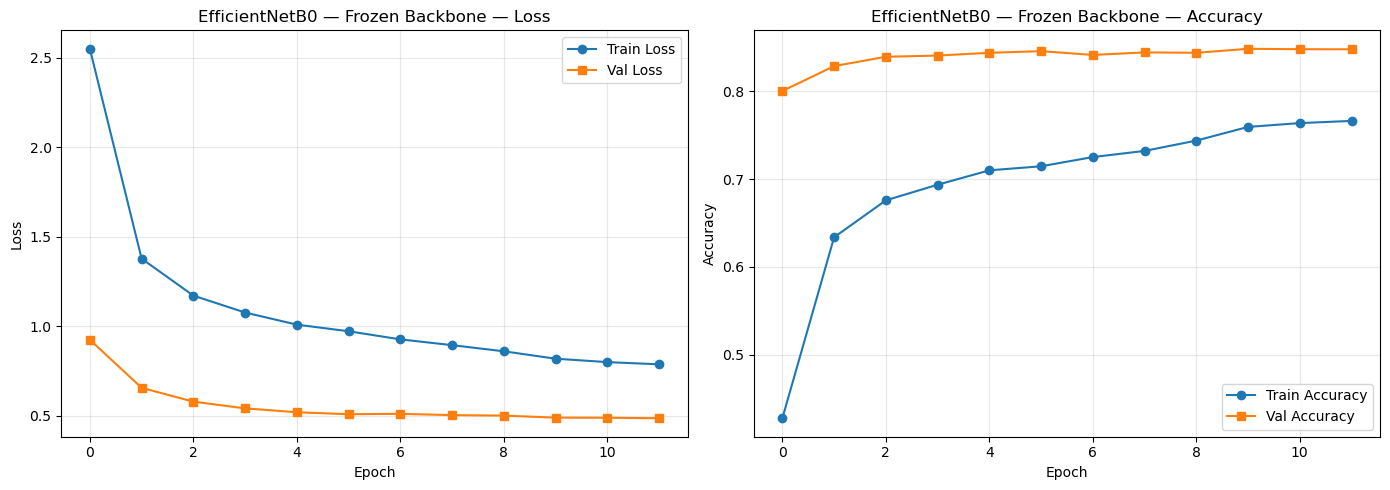

In [9]:
# Plot training history
os.makedirs(cfg["paths"]["evaluations"], exist_ok=True)

plot_training_history(
    history_frozen.history,
    title="EfficientNetB0 — Frozen Backbone",
    save_path=os.path.join(cfg["paths"]["evaluations"], "efficientnetb0_frozen_history.png"),
)

In [10]:
# save training history
os.makedirs(cfg["paths"]["histories"], exist_ok=True)
with open(os.path.join(cfg["paths"]["histories"], "efficientnetb0_frozen.json"), "w") as f:
    json.dump(history_frozen.history, f, indent=2)

print("Frozen training history saved.")

Frozen training history saved.


### 5. Phase 2: Fine-Tuning

For fine-tuning, the top layers of ResNet50 are unfrozen, batch
normalization layers kept frozen and a smaller learning rate is used to preserve
pretrained features.


In [11]:
from src.models.efficientnetb0 import unfreeze_layers


unfreeze_layers(model, unfreeze_top_n=5)
trainable, non_trainable = count_trainable_params(model)
print(f"\nAfter unfreezing top 5 layers:")
print(f"Trainable parameters: {trainable:,}")
print(f"Non-trainable parameters: {non_trainable:,}")
print(f"Total parameters: {trainable + non_trainable:,}")


After unfreezing top 5 layers:
Trainable parameters: 931,960
Non-trainable parameters: 3,271,331
Total parameters: 4,203,291


In [12]:
# compile model for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=cfg['training']['finetune']['initial_lr_efficientnetb0']),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top_5_accuracy"),
    ],
)
print(f"Fine-tuning learning rate: {cfg['training']['finetune']['initial_lr_efficientnetb0']}")


Fine-tuning learning rate: 3e-05


In [13]:
# set callbacks for fine-tuning
callbacks_finetune = create_callbacks(
    checkpoint_path=os.path.join(cfg["paths"]["checkpoints"], "efficientnetb0_finetuned.keras"),
    monitor="val_accuracy",
    mode="max",
    early_stop_patience=cfg["training"]["finetune"]["early_stop_patience"],
    reduce_lr_patience=cfg["training"]["finetune"]["reduce_lr_patience"],
    reduce_lr_factor=cfg["training"]["finetune"]["reduce_lr_factor"],
)

In [14]:
# train model for fine-tuning
history_finetune = model.fit(
    train_prep,
    validation_data=val_prep,
    epochs=cfg["training"]["finetune"]["epochs"],
    callbacks=callbacks_finetune,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7677 - loss: 0.7895 - top_5_accuracy: 0.9559
Epoch 1: val_accuracy improved from None to 0.84918, saving model to ../artefacts/checkpoints\efficientnetb0_finetuned.keras

Epoch 1: finished saving model to ../artefacts/checkpoints\efficientnetb0_finetuned.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 909s 2s/step - accuracy: 0.7701 - loss: 0.7697 - top_5_accuracy: 0.9566 - val_accuracy: 0.8492 - val_loss: 0.4826 - val_top_5_accuracy: 0.9862 - learning_rate: 3.0000e-05
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7661 - loss: 0.7792 - top_5_accuracy: 0.9577
Epoch 2: val_accuracy improved from 0.84918 to 0.84930, saving model to ../artefacts/checkpoints\efficientnetb0_finetuned.keras

Epoch 2: finished saving model to ../artefacts/checkpoints\efficientnetb0_finetuned.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 865s 2s/step - accuracy: 0.7709 - loss: 0.7639 - top_5_accuracy: 0.9578 - val_accuracy: 0.8493 - val_loss: 0.4826 - 

In [15]:
# evaluate fine-tuned model
results_finetune = evaluate_model(model, val_prep, verbose=1)
print("Fine-Tuned Model Evaluation:")
print(f"\nLoss: {results_finetune['loss']:.4f}")
print(f"Accuracy: {results_finetune['accuracy']:.4f}")
print(f"Top-5 Accuracy: {results_finetune['top_5_accuracy']:.4f}")

269/269 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - accuracy: 0.8513 - loss: 0.4822 - top_5_accuracy: 0.9865
Fine-Tuned Model Evaluation:

Loss: 0.4822
Accuracy: 0.8513
Top-5 Accuracy: 0.9865


Saved plot to ../artefacts/evaluations\efficientnetb0_finetuned_history.png


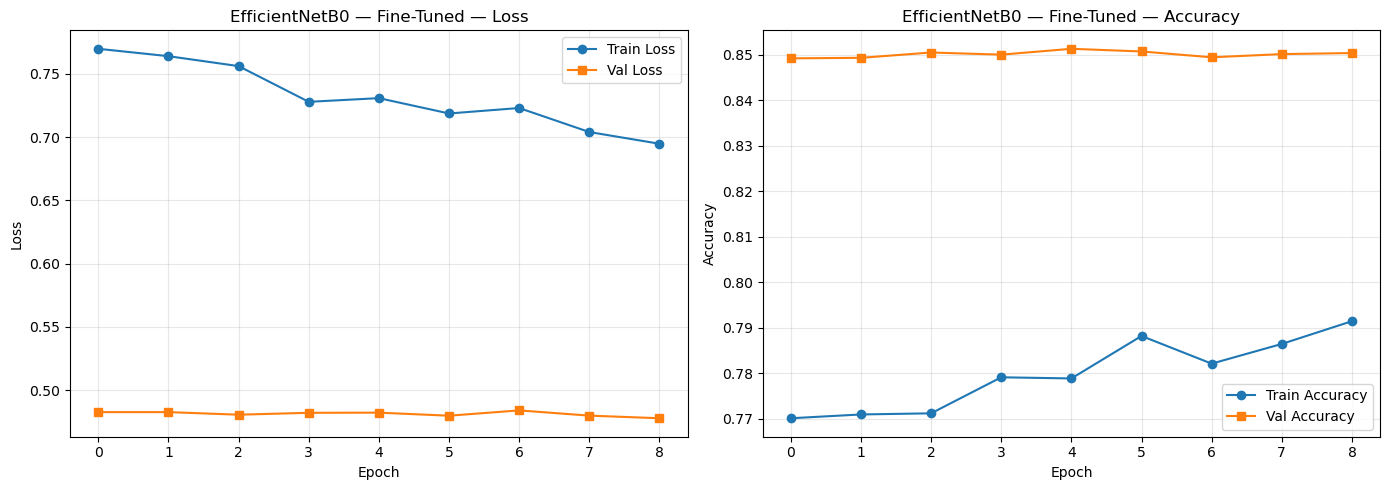

In [16]:
# Plot training history
plot_training_history(
    history_finetune.history,
    title="EfficientNetB0 — Fine-Tuned",
    save_path=os.path.join(cfg["paths"]["evaluations"], "efficientnetb0_finetuned_history.png"),
)

In [17]:
# save fine-tuning history
with open(os.path.join(cfg["paths"]["histories"], "efficientnetb0_finetuned.json"), "w") as f:
    json.dump(history_finetune.history, f, indent=2)

print("Fine-tuning training history saved successfully.")

Fine-tuning training history saved successfully.


### 6. Compare Frozen vs Fine-Tuned

Saved plot to ../artefacts/evaluations\efficientnetb0_comparison.png


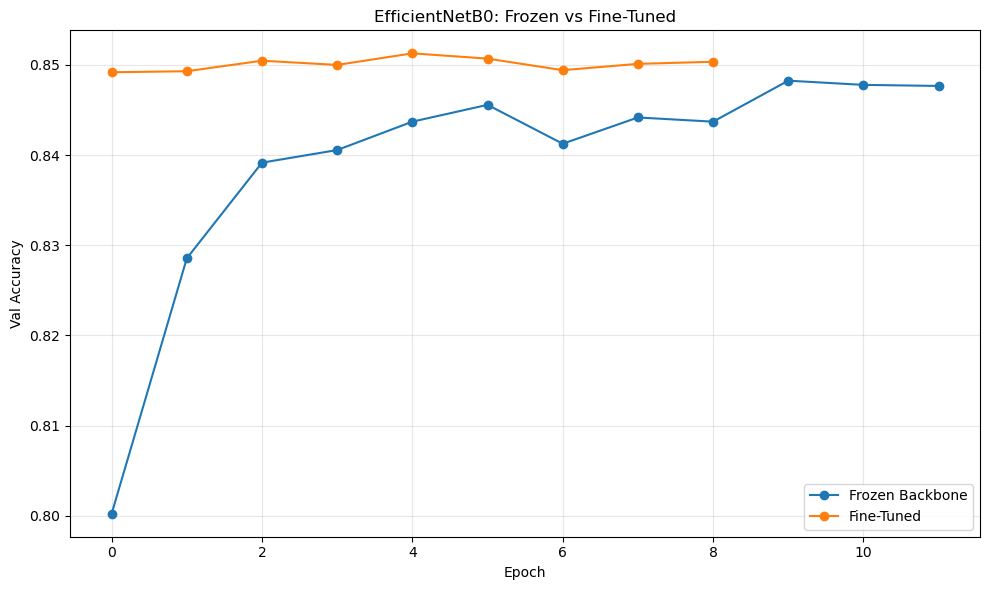

In [18]:
from src.evaluation.viz import plot_multiple_histories, models_comparison

histories = {
    "Frozen Backbone": history_frozen.history,
    "Fine-Tuned": history_finetune.history,
}

plot_multiple_histories(
    histories,
    metric="val_accuracy",
    title="EfficientNetB0: Frozen vs Fine-Tuned",
    save_path=os.path.join(cfg["paths"]["evaluations"], "efficientnetb0_comparison.png"),
)

In [19]:
# Print comparison table
comparison = {
    "EfficientNetB0 Frozen": results_frozen,
    "EfficientNetB0 Fine-Tuned": results_finetune,
}

models_comparison(comparison)

Model                              accuracy         loss top_5_accuracy
EfficientNetB0 Frozen                    0.8483           0.4886           0.9861 
EfficientNetB0 Fine-Tuned                0.8513           0.4822           0.9865 


### 7. Evaluations

The fine-tuned model is evaluated and confusion matrix, per-class metrics and top confused pairs are visualized.

In [20]:
# predict on test set
from src.evaluation.metrics import get_predictions, compute_confusion_matrix

y_pred, y_true = get_predictions(model, val_prep)
print(f"Predictions shape: {y_pred.shape}")
print(f"True labels shape: {y_true.shape}")

Predictions shape: (8580,)
True labels shape: (8580,)


Saved plot to ../artefacts/evaluations\efficientnetb0_confusion_matrix.png


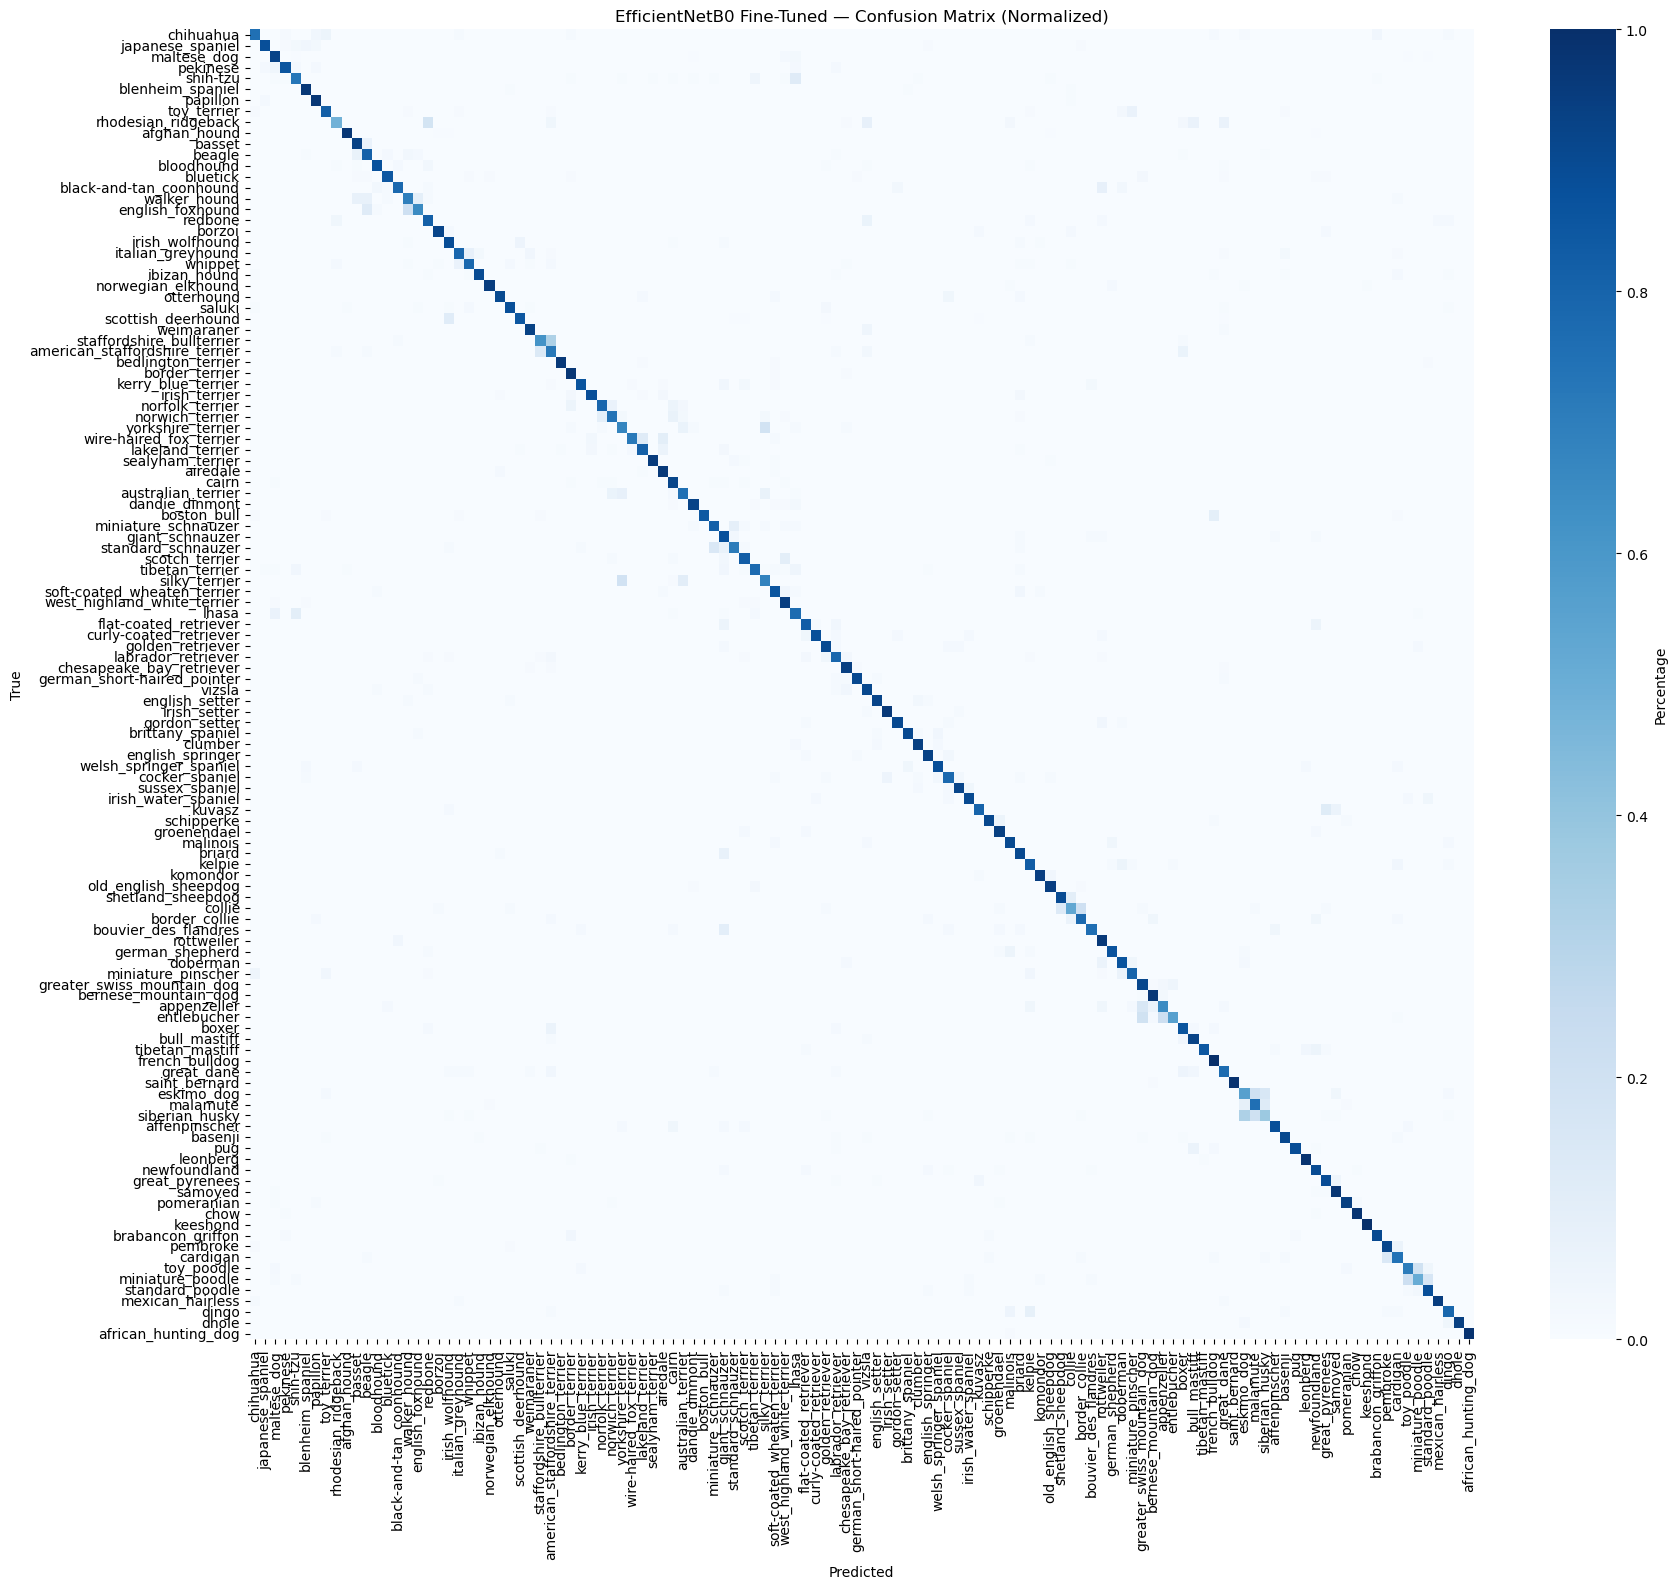

In [21]:
# plot confusion matrix
from src.evaluation.viz import plot_confusion_matrix

cm = compute_confusion_matrix(y_true, y_pred, num_classes)

plot_confusion_matrix(
    cm,
    class_names,
    normalize=True,
    title="EfficientNetB0 Fine-Tuned — Confusion Matrix (Normalized)",
    figsize=(18, 16),
    save_path=os.path.join(cfg["paths"]["evaluations"], "efficientnetb0_confusion_matrix.png"),
)

Top 10 Most Confused Pairs:
 1.                 siberian_husky → eskimo_dog                     :  30 errors
 2.                    entlebucher → appenzeller                    :  22 errors
 3.                    entlebucher → greater_swiss_mountain_dog     :  20 errors
 4.                 siberian_husky → malamute                       :  19 errors
 5.      staffordshire_bullterrier → american_staffordshire_terrier :  18 errors
 6.                  silky_terrier → yorkshire_terrier              :  16 errors
 7.             scottish_deerhound → irish_wolfhound                :  15 errors
 8.                       shih-tzu → lhasa                          :  14 errors
 9.            rhodesian_ridgeback → redbone                        :  13 errors
10.               english_foxhound → walker_hound                   :  12 errors
Saved plot to ../artefacts/evaluations\efficientnetb0_confused_pairs.png


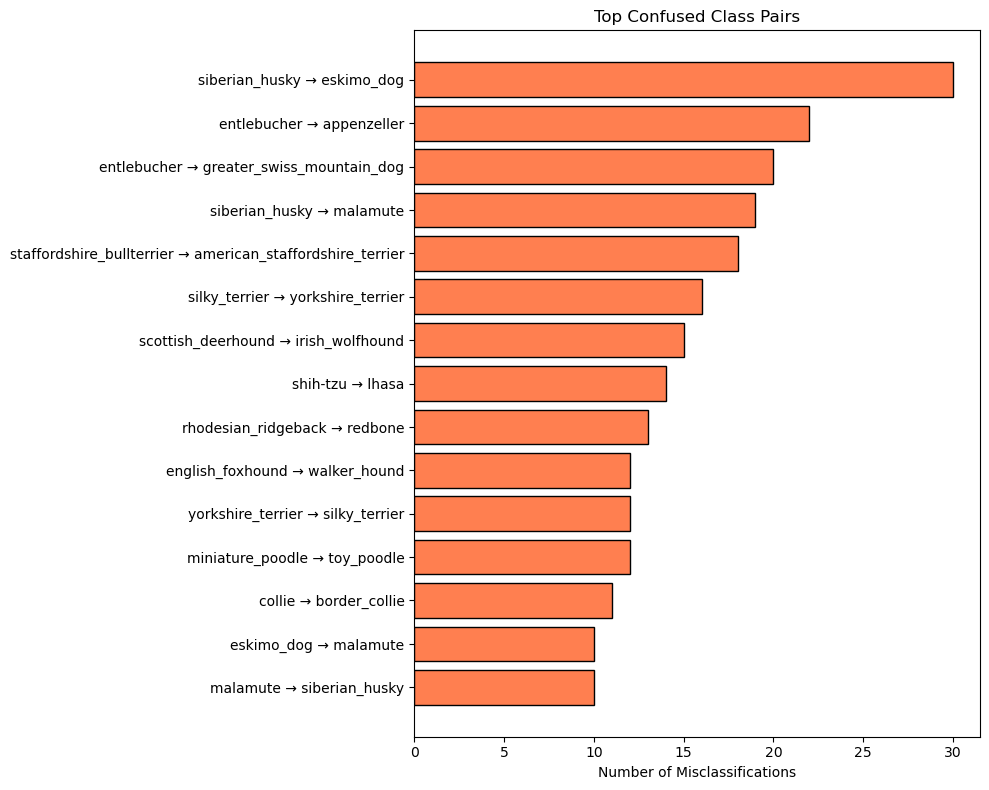

In [22]:
# plot top confused pairs
from src.evaluation.metrics import top_confused_pairs
from src.evaluation.viz import plot_top_k_confusion_pairs

confused_pairs = top_confused_pairs(cm, class_names, top_k=15)

print("Top 10 Most Confused Pairs:")
for i, (true_cls, pred_cls, count) in enumerate(confused_pairs[:10], 1):
    print(f"{i:2d}. {true_cls:>30s} → {pred_cls:<30s} : {count:3d} errors")

plot_top_k_confusion_pairs(
    confused_pairs,
    top_k=15,
    save_path=os.path.join(cfg["paths"]["evaluations"], "efficientnetb0_confused_pairs.png"),
)

10 Worst Performing Classes (by F1):
                    eskimo_dog  F1=0.467  Precision=0.400  Recall=0.560
                siberian_husky  F1=0.476  Precision=0.636  Recall=0.380
              miniature_poodle  F1=0.577  Precision=0.667  Recall=0.509
                   appenzeller  F1=0.595  Precision=0.550  Recall=0.647
                        collie  F1=0.596  Precision=0.683  Recall=0.528
           rhodesian_ridgeback  F1=0.619  Precision=0.854  Recall=0.486
american_staffordshire_terrier  F1=0.626  Precision=0.554  Recall=0.719
             yorkshire_terrier  F1=0.637  Precision=0.606  Recall=0.672
     staffordshire_bullterrier  F1=0.673  Precision=0.739  Recall=0.618
                  walker_hound  F1=0.679  Precision=0.661  Recall=0.698
Saved plot to ../artefacts/evaluations\efficientnetb0_worst_classes.png


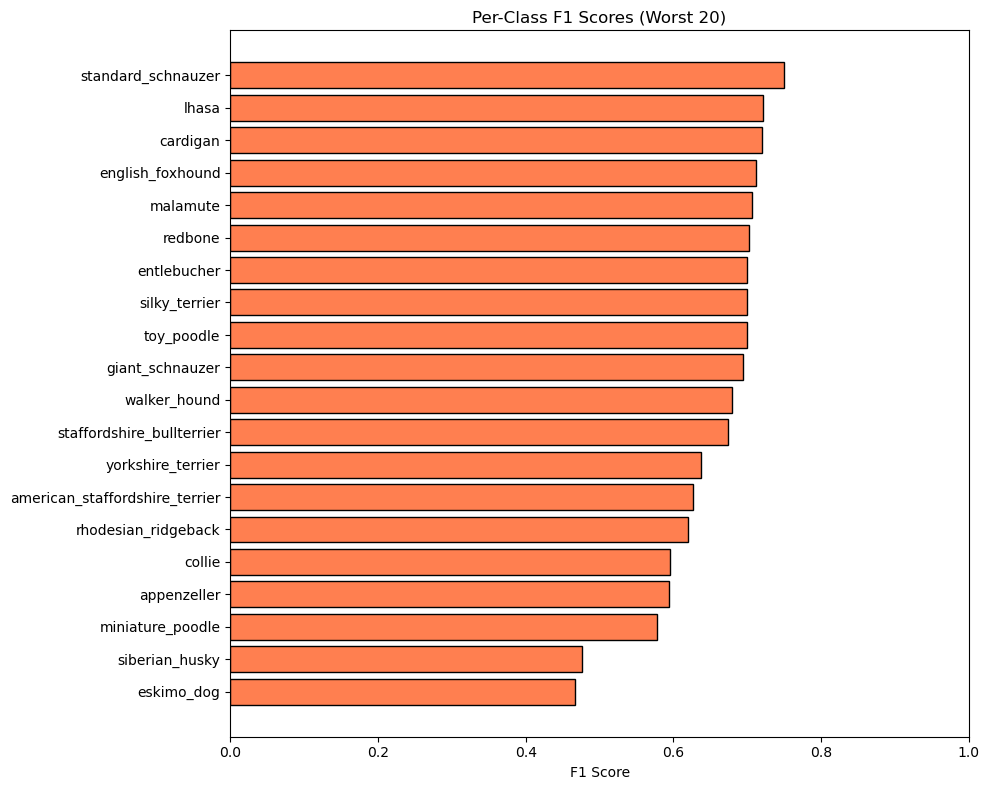

In [24]:
# per class metrics
from src.evaluation.metrics import get_per_class_metrics
from src.evaluation.viz import plot_per_class_f1

per_class_metrics = get_per_class_metrics(y_true, y_pred, class_names)

print("10 Worst Performing Classes (by F1):")
worst_10 = list(per_class_metrics.items())[:10]
for name, scores in worst_10:
    print(f"{name:>30s}  F1={scores['f1']:.3f}  Precision={scores['precision']:.3f}  Recall={scores['recall']:.3f}")

plot_per_class_f1(
    per_class_metrics,
    top_n=20,
    worst=True,
    save_path=os.path.join(cfg["paths"]["evaluations"], "efficientnetb0_worst_classes.png"),
)

In [25]:
from tensorflow.keras.utils import plot_model

# Ensure directory exists
os.makedirs(cfg["paths"]["architecture_diagrams"], exist_ok=True)

# Save architecture diagram
plot_model(
    model,
    to_file=os.path.join(cfg["paths"]["architecture_diagrams"], "efficientnetb0_architecture.png"),
    show_shapes=True,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=False,
    dpi=150,
)

print("✓ Saved model architecture diagram")

✓ Saved model architecture diagram


### 8. Summary

**Frozen Backbone Results:**
- Val Accuracy: 84.83%
- Val Top-5 Accuracy: 98.61%
- Val Loss: 0.4886
- Trainable Parameters ≈ 153,720 (classifier head only)

**Fine-Tuned Results:**
- Val Accuracy: 85.13%
- Val Top-5 Accuracy: 98.65%
- Val Loss: 0.4822
- Trainable Parameters: 931,960
- Improvement over Frozen: 0.36%

**Key Observations:**
- Top confused pairs are likely within breed families (spaniels, retrievers, terriers)
- Classes with low F1 scores may have fewer test samples 
- Fine‑tuning yields small accuracy gains here at the cost of substantially more trainable parameters and compute

**Comparison with ResNet50:**
- EfficientNetB0 typically achieves higher accuracy than ResNet50 with fewer parameters
- Check notebook 05 for detailed model comparison